Predict hand gesture and predict alphabet sign languange

Dataset :
- https://www.kaggle.com/datasets/ayuraj/asl-dataset


In [161]:
import torch
import torchvision
from torch.utils.data import ConcatDataset, DataLoader, random_split, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

In [162]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [163]:
import kagglehub
from pathlib import Path

source_path = Path(kagglehub.dataset_download("ayuraj/asl-dataset"))
print("Source path:", source_path)
print("Isi source:", os.listdir(source_path))

Using Colab cache for faster access to the 'asl-dataset' dataset.
Source path: /kaggle/input/asl-dataset
Isi source: ['asl_dataset']


In [164]:
from pathlib import Path
import kagglehub
import shutil
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


def create_asl_dataloaders(
    root: str,
    transform_train: transforms.Compose,
    transform_test: transforms.Compose,
    batch_size: int,
    num_workers: int = 4,
):
    source_path = Path(kagglehub.dataset_download("ayuraj/asl-dataset")) / "asl_dataset"
    destination_path = Path(root) / "asl-dataset"

    if not destination_path.exists():
        destination_path.mkdir(parents=True)
        for item in source_path.iterdir():
            if item.is_dir() and item.name != "asl_dataset":
                shutil.copytree(item, destination_path / item.name)

    full_dataset = datasets.ImageFolder(root=destination_path, transform=transform_train)
    print("ASL Classes:", full_dataset.classes)

    train_size = int(len(full_dataset) * 0.8)
    test_size = len(full_dataset) - train_size
    generator = torch.Generator().manual_seed(42)

    data_train, data_test = random_split(full_dataset, [train_size, test_size], generator=generator)

    train_loader = DataLoader(data_train, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    test_loader = DataLoader(data_test, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    class_names = full_dataset.classes
    print("Train:", len(data_train), "| Test:", len(data_test))

    return train_loader, test_loader, data_train, data_test, class_names

In [165]:
import torch
import torchvision
from timeit import default_timer as timer
from tqdm.auto import tqdm
from typing import Dict, List, Tuple
from pathlib import Path
from PIL import Image, ImageOps


def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device) -> Tuple[float, float]:

  model.train()

  train_loss, train_acc = 0, 0

  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)

    y_pred = model(X)

    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    y_pred_class = torch.argmax(y_pred, dim=1)
    train_acc += (y_pred_class == y).sum().item() / len(y_pred)

  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)

  return train_loss, train_acc


def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.dataloader,
              loss_fn: torch.nn.Module,
              device: torch.device) -> Tuple[float, float]:

  model.eval()

  test_loss, test_acc = 0,0

  with torch.inference_mode():
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)

      test_pred_logits = model(X)

      loss = loss_fn(test_pred_logits, y)
      test_loss += loss.item()

      test_pred_labels = test_pred_logits.argmax(dim=1)
      test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))

    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)

    return test_loss, test_acc


def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          epochs: int,
          device: torch.device) -> Dict[str, List]:

  results = {"train_loss": [],
             "train_acc": [],
             "test_loss": [],
             "test_acc": []}

  train_start_time = timer()

  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(model=model,
                                       dataloader=train_dataloader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer,
                                       device=device)

    test_loss, test_acc = test_step(model=model,
                                    dataloader=test_dataloader,
                                    loss_fn=loss_fn,
                                    device=device)

    print(f"epoch : {epoch + 1} | train_loss : {train_loss:.4f} | train_acc : {train_acc:.4f} | test_loss : {test_loss:.4f} | test_acc : {test_acc:.4f}\n")

    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  train_end_time = timer()

  print(f"Waktu Yang Dibutuhkan Training : {train_end_time - train_start_time:.3f} seconds")

  return results

def predict(model, image_path, device, transform=None):
    if device is None:
        device = next(model.parameters()).device

    image = Image.open(image_path).convert("RGB")

    if transform is not None:
        image = transform(image)

    image = image.unsqueeze(0).to(device)
    model.to(device)
    model.eval()

    with torch.inference_mode():
        logits = model(image)
        probs = torch.softmax(logits, dim=1)

    pred = probs.argmax(dim=1).item()
    prob = probs.max().item()
    return pred, prob

In [166]:
import torch
from pathlib import Path


def save_checkpoint(
    model: torch.nn.Module,
    model_path: str | Path,
    class_names: list[str],
):
    model_path = Path(model_path)
    model_path.parent.mkdir(parents=True, exist_ok=True)

    checkpoint = {
        "model_state_dict": model.state_dict(),
        "class_names": class_names,
    }

    torch.save(checkpoint, model_path)

    print(f"[INFO] Checkpoint saved to: {model_path}")

In [167]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

In [168]:
train_loader, test_loader, data_train, data_test, class_names = create_asl_dataloaders(
    root="data",
    transform_train=train_transform,
    transform_test=test_transform,
    batch_size=32,
)

Using Colab cache for faster access to the 'asl-dataset' dataset.
ASL Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Train: 2012 | Test: 503


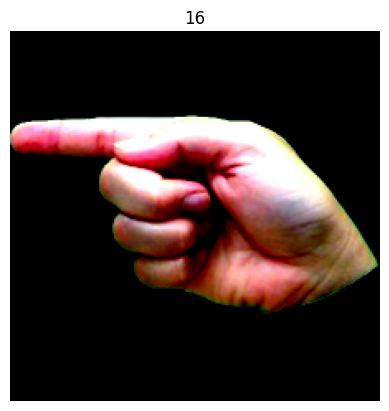

In [169]:
img, label = data_test[0]

plt.imshow(img.permute(1, 2, 0) * 0.5 + 0.5)
plt.title(label)
plt.axis("off")
plt.show()

In [170]:
def test_accuracy(model, dataset, device):
    loader = DataLoader(
        dataset,
        batch_size=32,
        shuffle=False
    )

    model.eval()

    correct = 0
    total = 0

    with torch.inference_mode():
        for image, label in loader:
            image = image.to(device)
            label = label.to(device)

            logits = model(image)
            pred = logits.argmax(dim=1)

            correct += (pred == label).sum().item()
            total += label.size(0)

    return correct / total

In [171]:
weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)

model.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1280, out_features=len(class_names))
)

model = model.to(device)

model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

Check Before Training Accuracy

In [172]:

model_acc = test_accuracy(
    model,
    data_test,
    device
)

print(f"Data Accuracy Before: {model_acc:.2%}")

Data Accuracy Before: 1.39%


In [173]:
for param in model.features.parameters():
    param.requires_grad = False

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.classifier.parameters(), lr=1e-3)

Check Accuracy with small datasets

In [174]:
X, y = next(iter(train_loader))

X = X.to(device)

model.eval()

with torch.no_grad():
    out = model(X)

print(out.shape)
print(out[0])

torch.Size([32, 36])
tensor([ 0.0261,  0.1765, -0.1313, -0.4663,  0.1439, -0.1927,  0.0582, -0.4201,
         0.2289,  0.1158,  0.1020,  0.6172, -0.0281, -0.0286,  0.3474,  0.0042,
        -0.0117, -0.1756,  0.2637, -0.2864,  0.0290,  0.1209,  0.3335, -0.0089,
         0.0781, -0.2280, -0.3023,  0.0776, -0.1841,  0.2169, -0.2626, -0.2186,
         0.3556, -0.4338, -0.2105, -0.0624], device='cuda:0')


In [175]:
train_indices = torch.randperm(len(data_train))[:100]
test_indices = torch.randperm(len(data_test))[:100]

train_subset = Subset(data_train, train_indices)
test_subset = Subset(data_test, test_indices)

len(train_subset), len(test_subset)

(100, 100)

In [176]:
train_subset_loader = DataLoader(
    train_subset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
)

test_subset_loader = DataLoader(
    test_subset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
)

len(train_subset), len(test_subset)

(100, 100)

In [177]:
results = train(
    model=model,
    train_dataloader=train_subset_loader,
    test_dataloader=test_subset_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=20,
    device=device
)

  0%|          | 0/20 [00:00<?, ?it/s]

epoch : 1 | train_loss : 3.5584 | train_acc : 0.0391 | test_loss : 3.6115 | test_acc : 0.0312

epoch : 2 | train_loss : 3.2501 | train_acc : 0.1797 | test_loss : 3.6468 | test_acc : 0.0938

epoch : 3 | train_loss : 3.0942 | train_acc : 0.2500 | test_loss : 3.6509 | test_acc : 0.0938

epoch : 4 | train_loss : 2.9287 | train_acc : 0.2734 | test_loss : 3.6695 | test_acc : 0.1250

epoch : 5 | train_loss : 2.7907 | train_acc : 0.3047 | test_loss : 3.6254 | test_acc : 0.1641

epoch : 6 | train_loss : 2.6390 | train_acc : 0.5000 | test_loss : 3.5551 | test_acc : 0.1641

epoch : 7 | train_loss : 2.4534 | train_acc : 0.5859 | test_loss : 3.4951 | test_acc : 0.2031

epoch : 8 | train_loss : 2.4822 | train_acc : 0.5000 | test_loss : 3.5303 | test_acc : 0.2500

epoch : 9 | train_loss : 2.4132 | train_acc : 0.4688 | test_loss : 3.4762 | test_acc : 0.1953

epoch : 10 | train_loss : 2.3001 | train_acc : 0.5703 | test_loss : 3.4995 | test_acc : 0.2188

epoch : 11 | train_loss : 2.0482 | train_acc : 0.

Lets Train Large Datasets

In [178]:
for param in model.features.parameters():
    param.requires_grad = False

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.classifier.parameters(), lr=1e-3)

results_stage1 = train(
    model=model,
    train_dataloader=train_loader,
    test_dataloader=test_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=3,          # classifier yang dilatih
    device=device
)

  0%|          | 0/3 [00:00<?, ?it/s]

epoch : 1 | train_loss : 2.2931 | train_acc : 0.4732 | test_loss : 1.6795 | test_acc : 0.6111

epoch : 2 | train_loss : 1.6188 | train_acc : 0.6481 | test_loss : 1.3532 | test_acc : 0.7029

epoch : 3 | train_loss : 1.3245 | train_acc : 0.7105 | test_loss : 1.1010 | test_acc : 0.7536

Waktu Yang Dibutuhkan Training : 35.474 seconds


In [179]:
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-4)

results_stage2 = train(
    model=model,
    train_dataloader=train_loader,
    test_dataloader=test_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=5,
    device=device
)

  0%|          | 0/5 [00:00<?, ?it/s]

epoch : 1 | train_loss : 0.8148 | train_acc : 0.7992 | test_loss : 0.4206 | test_acc : 0.8910

epoch : 2 | train_loss : 0.4656 | train_acc : 0.8759 | test_loss : 0.3799 | test_acc : 0.8871

epoch : 3 | train_loss : 0.3721 | train_acc : 0.8936 | test_loss : 0.2983 | test_acc : 0.9086

epoch : 4 | train_loss : 0.2735 | train_acc : 0.9204 | test_loss : 0.2215 | test_acc : 0.9235

epoch : 5 | train_loss : 0.2441 | train_acc : 0.9369 | test_loss : 0.1592 | test_acc : 0.9406

Waktu Yang Dibutuhkan Training : 71.914 seconds


In [187]:
save_checkpoint(model=model,
                           model_path="models/sign_languange_model_efficientnet_b0_trained_experiments.pth",
                           class_names=class_names)

[INFO] Checkpoint saved to: models/sign_languange_model_efficientnet_b0_trained_experiments.pth


In [188]:
correct = 0
total = 0

model.eval()

with torch.inference_mode():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"Correct : {correct}")
print(f"Total   : {total}")
print(f"Acc     : {correct/total:.4f}")

Correct : 469
Total   : 503
Acc     : 0.9324


Result 1

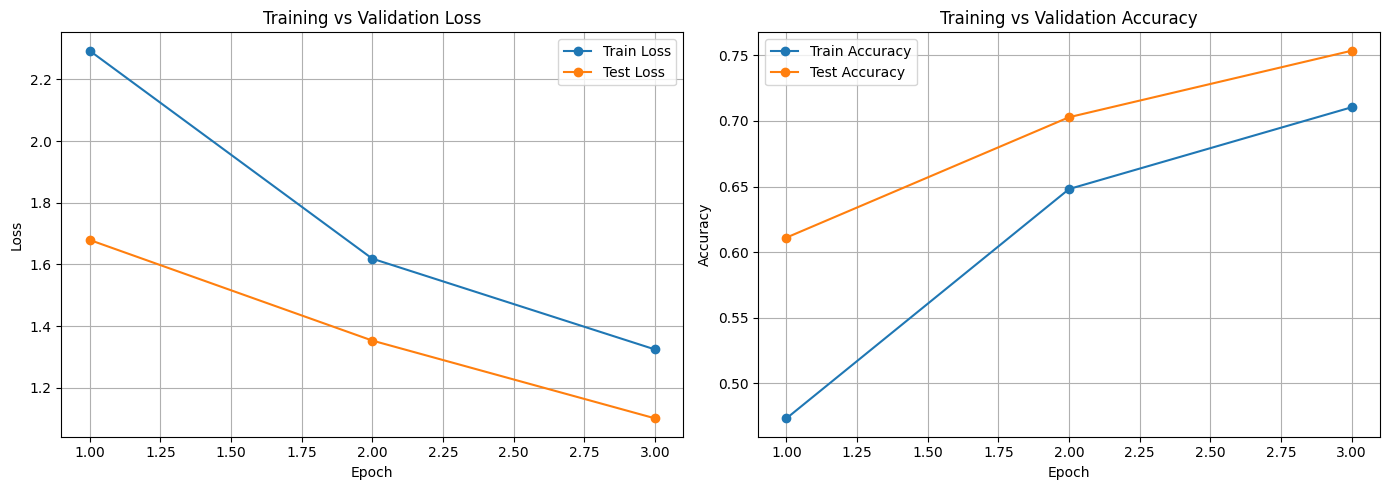

In [189]:
import matplotlib.pyplot as plt

train_loss = results_stage1["train_loss"]
test_loss = results_stage1["test_loss"]
train_acc = results_stage1["train_acc"]
test_acc = results_stage1["test_acc"]

epochs = range(1, len(train_loss) + 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax[0].plot(epochs, train_loss, label="Train Loss", marker="o")
ax[0].plot(epochs, test_loss, label="Test Loss", marker="o")
ax[0].set_title("Training vs Validation Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()
ax[0].grid(True)

# Accuracy
ax[1].plot(epochs, train_acc, label="Train Accuracy", marker="o")
ax[1].plot(epochs, test_acc, label="Test Accuracy", marker="o")
ax[1].set_title("Training vs Validation Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

Result 2

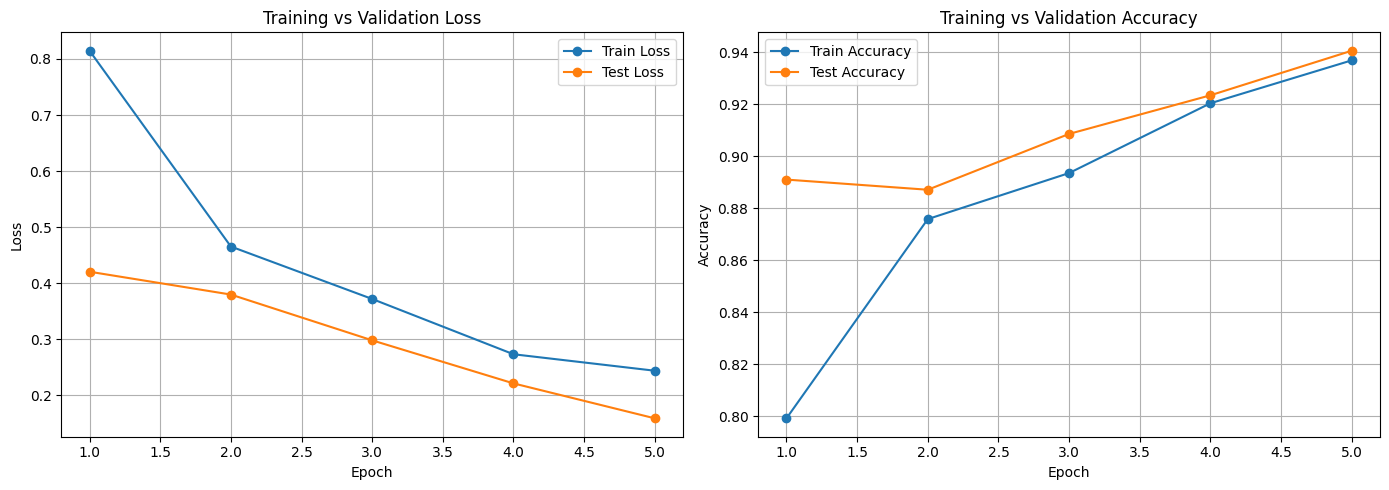

In [190]:
import matplotlib.pyplot as plt

train_loss = results_stage2["train_loss"]
test_loss = results_stage2["test_loss"]
train_acc = results_stage2["train_acc"]
test_acc = results_stage2["test_acc"]

epochs = range(1, len(train_loss) + 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax[0].plot(epochs, train_loss, label="Train Loss", marker="o")
ax[0].plot(epochs, test_loss, label="Test Loss", marker="o")
ax[0].set_title("Training vs Validation Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()
ax[0].grid(True)

# Accuracy
ax[1].plot(epochs, train_acc, label="Train Accuracy", marker="o")
ax[1].plot(epochs, test_acc, label="Test Accuracy", marker="o")
ax[1].set_title("Training vs Validation Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

Accuracy After Training

In [191]:
model_acc = test_accuracy(
    model,
    data_test,
    device
)

print(f"Data Accuracy After Training : {model_acc:.2%}")

Data Accuracy After Training : 93.24%


Lest Prediction

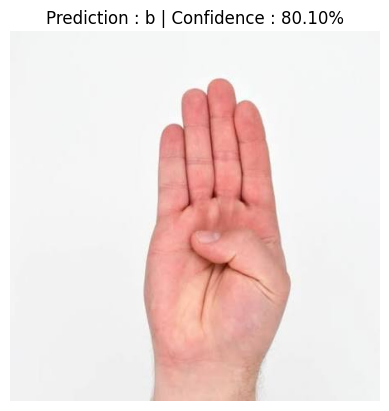

In [192]:
from PIL import Image

path_data = Path("data/")
image_path = path_data / "prediction_image/predict_image1.jpg"

image = Image.open(image_path)

transforms_pred = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

pred, prob = predict(
    model=model,
    image_path=image_path,
    device=device,
    transform=transforms_pred,
)

plt.imshow(image)
plt.title(f"Prediction : {class_names[pred]} | Confidence : {prob:.2%}")
plt.axis("off")
plt.show()

In [193]:
# import shutil
# shutil.rmtree("data/asl-dataset", ignore_errors=True)